### Part 3 - Paper Replication 

### Packages 

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from scipy.stats import skew
from scipy.stats import kurtosis
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
import matplotlib.gridspec as gridspec

### Getting my replication data

In [14]:

# Path on my computer, change it to your path if you want to run the code
Anderson_Cesa_Data_Path = Path("/Users/lorenzouberti/Desktop/Monetary-and-Financial-Macroeconometrics-Project/MONETARY AND FINANCIAL ECONOMICS/Cesa Biachi Data /1-s2-2/CTV_DATA.xlsx")
Anderson_Cesa_Data_HFI = pd.read_excel(Anderson_Cesa_Data_Path, sheet_name="HFI")
Anderson_Cesa_Data_HFI_surprise = pd.read_excel(Anderson_Cesa_Data_Path, sheet_name="HFI_surprise")
Anderson_Cesa_Data_Shocks_Long = pd.read_excel(Anderson_Cesa_Data_Path, sheet_name="Shocks_Long")
Anderson_Cesa_Final_Data_Frame = Anderson_Cesa_Data_HFI.copy()
Anderson_Cesa_Data_HFI["month"] = pd.PeriodIndex(Anderson_Cesa_Data_HFI["month"].str.replace("m", "-", regex=False),freq="M")
Anderson_Cesa_Data_HFI_surprise["month"] = pd.PeriodIndex(Anderson_Cesa_Data_HFI_surprise["month"].str.replace("m", "-", regex=False),freq="M")
# Merging the shocks surprise dat with base data frame for simplicity. 
Anderson_Cesa_Final_Data_Frame = Anderson_Cesa_Data_HFI.merge(Anderson_Cesa_Data_HFI_surprise, on="month", how="left")
Anderson_Cesa_Final_Data_Frame.head()

Anderson_Cesa_replication_df['i_1YR'] = Anderson_Cesa_replication_df['i_1YR'] * 100


### Descriptive Statistics

In [15]:

# Selcting only numeric columns for descriptive statistics
numeric = Anderson_Cesa_Final_Data_Frame.select_dtypes(include='number')

descriptive_stats = numeric.describe().T

# Adding skewness and kurtosis to the descriptive statistics
descriptive_stats['skewness'] = numeric.apply(skew, axis=0, bias=False)
descriptive_stats['kurtosis'] = numeric.apply(kurtosis, axis=0, fisher=False, bias=False)

wanted = ['i_1YR','unempl','fxbis','gdp','corp_spread',
          'mortg_spread','cred','equity','tb','us_baa',
          'CPI','cm2','cloyne']   

summary_table = descriptive_stats.loc[wanted, 
    ['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis']
].round(3)

print(summary_table)


              count          mean           std    min    25%           50%  \
i_1YR         427.0  6.600000e-02  4.000000e-02  0.002  0.043  6.000000e-02   
unempl        427.0  7.600000e-02  2.100000e-02  0.046  0.056  7.700000e-02   
fxbis         427.0  4.779000e+00  1.280000e-01  4.531  4.667  4.804000e+00   
gdp           427.0  4.331000e+00  2.430000e-01  3.903  4.164  4.333000e+00   
corp_spread   427.0  1.454000e+00  8.910000e-01 -0.068  0.867  1.263000e+00   
mortg_spread  427.0  9.320000e-01  1.248000e+00 -2.810  0.095  8.100000e-01   
cred          427.0  3.812000e+00  7.210000e-01  2.410  3.340  3.843000e+00   
equity        427.0  3.871000e+00  7.680000e-01  1.987  3.456  4.125000e+00   
tb            427.0  4.336890e+07  5.900404e+07 -0.121 -0.016  1.530000e-01   
us_baa        427.0  2.255183e+07  4.775911e+07  1.290  1.800  2.403000e+00   
CPI           427.0  4.336890e+07  5.900404e+07  1.788  1.864  1.941000e+00   
cm2           427.0  6.216208e+07  6.179928e+07 -0.4

Step By Step Replication to Estimate

In [16]:
# Applying Log Levels since the VAR was estimated in log levels, stil following the Cesa et al. (2020) paper methodology of taking the log of the CPI and the NEER.
Anderson_Cesa_replication_df= Anderson_Cesa_Final_Data_Frame.copy()
# set the time as the primary column
Anderson_Cesa_replication_df = Anderson_Cesa_replication_df.set_index('month')
Anderson_Cesa_replication_df = Anderson_Cesa_replication_df.loc['1997-06':'2015-01']
Anderson_Cesa_replication_df



,i_1YR,unempl,fxbis,gdp,corp_spread,mortg_spread,cred,equity,tb,CPI,us_baa,cm2,cloyne
month,,,,,,,,,,,,,
1997-06,0.066621,0.070,4.777422,4.339275,0.513843,0.11,3.860719,4.265783,0.206868,1.846337,1.526667,0.05833,3.232462e-01
1997-07,0.069117,0.069,4.813646,4.346696,0.482519,0.44,3.864327,4.293794,0.247543,1.844477,1.526818,0.03484,5.400618e-01
1997-08,0.069654,0.067,4.794168,4.341318,0.490017,0.66,3.860859,4.317477,0.200352,1.846955,1.518095,-0.04388,2.777344e-01
1997-09,0.068997,0.065,4.777094,4.350227,0.488041,1.18,3.863373,4.331787,0.215191,1.848805,1.504286,-0.01800,-2.267061e-01
1997-10,0.069299,0.065,4.785342,4.356818,0.476160,1.49,3.859187,4.358982,0.185337,1.848805,1.542273,0.00742,-6.774127e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-09,0.004965,0.059,4.653390,4.682732,1.329107,0.45,4.593404,4.758818,-0.074312,2.001301,2.268095,-0.02200,1.234568e+08
2014-10,0.004600,0.058,4.653390,4.681776,1.418769,0.69,4.592848,4.704488,-0.073837,2.001734,2.383636,0.00000,1.234568e+08
2014-11,0.004153,0.056,4.651718,4.682732,1.441245,0.81,4.597590,4.741231,-0.031088,2.000434,2.459444,-0.02100,1.234568e+08


VAR Replication 

In [17]:
VAR_Zt_Variables = ['i_1YR', 'CPI', 'unempl', 'fxbis', 'corp_spread', 'mortg_spread', 'us_baa']
VAR_Zt_lables = ['One-Year Rate', 'CPI', 'Unemployment', 'Exchange Rate', 'Corporate Spread', 'Mortgage Spread', 'BAA Corp. Spread US']
VAR_instrumental_variable = 'cm2'
lags_p = 2
IRF_horizon_h = 41
number_of_booststrap_replications = 5000
confidence_level = 68 
shock_size = 0.0025
seed = 2

# For Scaling
#spread_vars = ['corp_spread', 'mortg_spread', 'us_baa']
#Anderson_Cesa_replication_df[spread_vars] = Anderson_Cesa_replication_df[spread_vars] * 100
#Anderson_Cesa_replication_df['i_1YR'] = Anderson_Cesa_replication_df['i_1YR'] * 100

Endogenous_var_values = Anderson_Cesa_replication_df[VAR_Zt_Variables].values
Instrumental_var_values = Anderson_Cesa_replication_df[[VAR_instrumental_variable]]
Instrumental_var_values = np.where(np.isnan(Instrumental_var_values),0.0, Instrumental_var_values)



Helper Functions --> Building a companion matrix, estimating the VAR, Proxy Var, Draw a MBB resample of residuals and matching instrument,Moving-Block Bootstrap inference for Proxy-SVAR, 

In [18]:
def build_companion(B, p):
    n = B.shape[0]
    top  = B
    eye  = np.eye(n * (p - 1), n * p)
    return np.vstack([top, eye])

def estimate_var(Y, p):
    T, n = Y.shape
    # Build RHS: lags + constant
    X = np.hstack([Y[p - 1 - l: T - 1 - l] for l in range(p)] +
                  [np.ones((T - p, 1))])          
    Yt = Y[p:]                                     
    # OLS
    B_full, _, _, _ = lstsq(X, Yt)                
    B_full = B_full.T                              
    B     = B_full[:, :-1]                         
    const = B_full[:, -1]                          
    resid = Yt - X @ B_full.T                      
    return B, const, resid, X, Yt

def proxy_svar_irf(B, const, resid, IV_trimmed, p, irhor):
    T_eff, n = resid.shape
    # Reduced-form covariance
    Sigma = (resid.T @ resid) / (T_eff - n * p - 1)

    # Partition residuals: u1 = first variable, u2 = rest
    u1 = resid[:, [0]]          
    u2 = resid[:, 1:]          

    # Proxy relevance / impact coefficients via IV regression
    # Stage 1: regress u1 on instrument
    m = IV_trimmed                                 
    valid = ~np.isnan(m[:, 0])
    m_v  = m[valid]
    u1_v = u1[valid]
    u2_v = u2[valid]

    # b21_b11_inv : OLS of u2 on u1 instrumented by m
    # First stage
    pi_hat, _, _, _ = lstsq(m_v, u1_v)            
    u1_hat = m_v @ pi_hat                          

    # Second stage
    b21_b11, _, _, _ = lstsq(u1_hat, u2_v)        
    b21_b11 = b21_b11.T                            

    # Recover impact vector
    b11_sq = (Sigma[0, 0]
              - (b21_b11.T @ Sigma[1:, 1:] @ b21_b11).item()
              ) / (1 + (b21_b11.T @ Sigma[1:, [0]]).item())
    # numerical fix
    b11_sq = float(np.abs(b11_sq))
    b11    = np.sqrt(b11_sq)
    b21    = b21_b11 * b11                         
    impact = np.vstack([[b11], b21])               

    # Build companion and compute IRFs
    A = build_companion(B, p)
    n_comp = A.shape[0]
    e1 = np.zeros(n_comp)
    e1[:n] = impact[:, 0]

    IRF = np.zeros((irhor, n))
    state = e1.copy()
    for h in range(irhor):
        IRF[h] = state[:n]
        state  = A @ state

    return IRF

def moving_block_bootstrap(resid, IV, block_size, T_full, p):
    
    T_eff = resid.shape[0]
    n_blocks = int(np.ceil(T_eff / block_size))
    max_start = T_eff - block_size
    starts = np.random.randint(0, max_start + 1, size=n_blocks)
    boot_resid = np.vstack([resid[s: s + block_size] for s in starts])[:T_eff]
    boot_iv    = np.vstack([IV[s: s + block_size]    for s in starts])[:T_eff]
    return boot_resid, boot_iv

def bootstrap_irfs(ENDO, IV, p, irhor, nboot, block_size, clevel, seed):
    np.random.seed(seed)
    T, n = ENDO.shape

    B, const, resid, X, Yt = estimate_var(ENDO, p)
    IV_trimmed = IV[p:]        # align with residuals

    irf_point = proxy_svar_irf(B, const, resid, IV_trimmed, p, irhor)

    boot_store = np.zeros((nboot, irhor, n))

    for b in range(nboot):
        # Draw bootstrap residuals and instrument
        b_resid, b_iv = moving_block_bootstrap(resid, IV_trimmed, block_size, T, p)

        # Reconstruct bootstrap ENDO series
        Y_boot = np.zeros((T, n))
        Y_boot[:p] = ENDO[:p]
        for t in range(p, T):
            lag_vec = np.hstack([Y_boot[t - l - 1] for l in range(p)])
            Y_boot[t] = B @ lag_vec + const + b_resid[t - p]

        B_b, const_b, resid_b, _, _ = estimate_var(Y_boot, p)
        try:
            irf_b = proxy_svar_irf(B_b, const_b, resid_b, b_iv, p, irhor)
            boot_store[b] = irf_b
        except Exception:
            boot_store[b] = irf_point  # fallback on numerical failure

    alpha = (100 - clevel) / 2
    irsL = np.percentile(boot_store, alpha,       axis=0)
    irsH = np.percentile(boot_store, 100 - alpha, axis=0)
    irsM = np.percentile(boot_store, 50,          axis=0)

    return irsL, irsM, irsH, irf_point


Running the Estimation

In [19]:
print("Estimating Proxy-SVAR and running MBB bootstrap …")
print(f"  Sample: {Anderson_Cesa_replication_df.index[0]} – {Anderson_Cesa_replication_df.index[-1]}")
print(f"  T = {Endogenous_var_values.shape[0]}, n = {Endogenous_var_values.shape[1]}, p = {lags_p}, bootstrap reps = {number_of_booststrap_replications}")

T    = Endogenous_var_values.shape[0]
BlockSize = int(np.floor(5.03 * T ** 0.25))
print(f"  Block size = {BlockSize}")

irsL, irsM, irsH, irf_point = bootstrap_irfs(
    Endogenous_var_values, Instrumental_var_values, lags_p, IRF_horizon_h, number_of_booststrap_replications, BlockSize, confidence_level, seed)

# Normalize so the impact response of i_1YR is +25 bps
target_impact = 0.25   # +25 bps = 0.25 percentage points

scale = target_impact / irf_point[0, 0]

irf_point *= scale
irsL      *= scale
irsM      *= scale
irsH      *= scale

# Keep CI ordered correctly
irsL, irsH = np.minimum(irsL, irsH), np.maximum(irsL, irsH)

Estimating Proxy-SVAR and running MBB bootstrap …
  Sample: 1997-06 – 2015-01
  T = 212, n = 7, p = 2, bootstrap reps = 5000
  Block size = 19


Visualisations

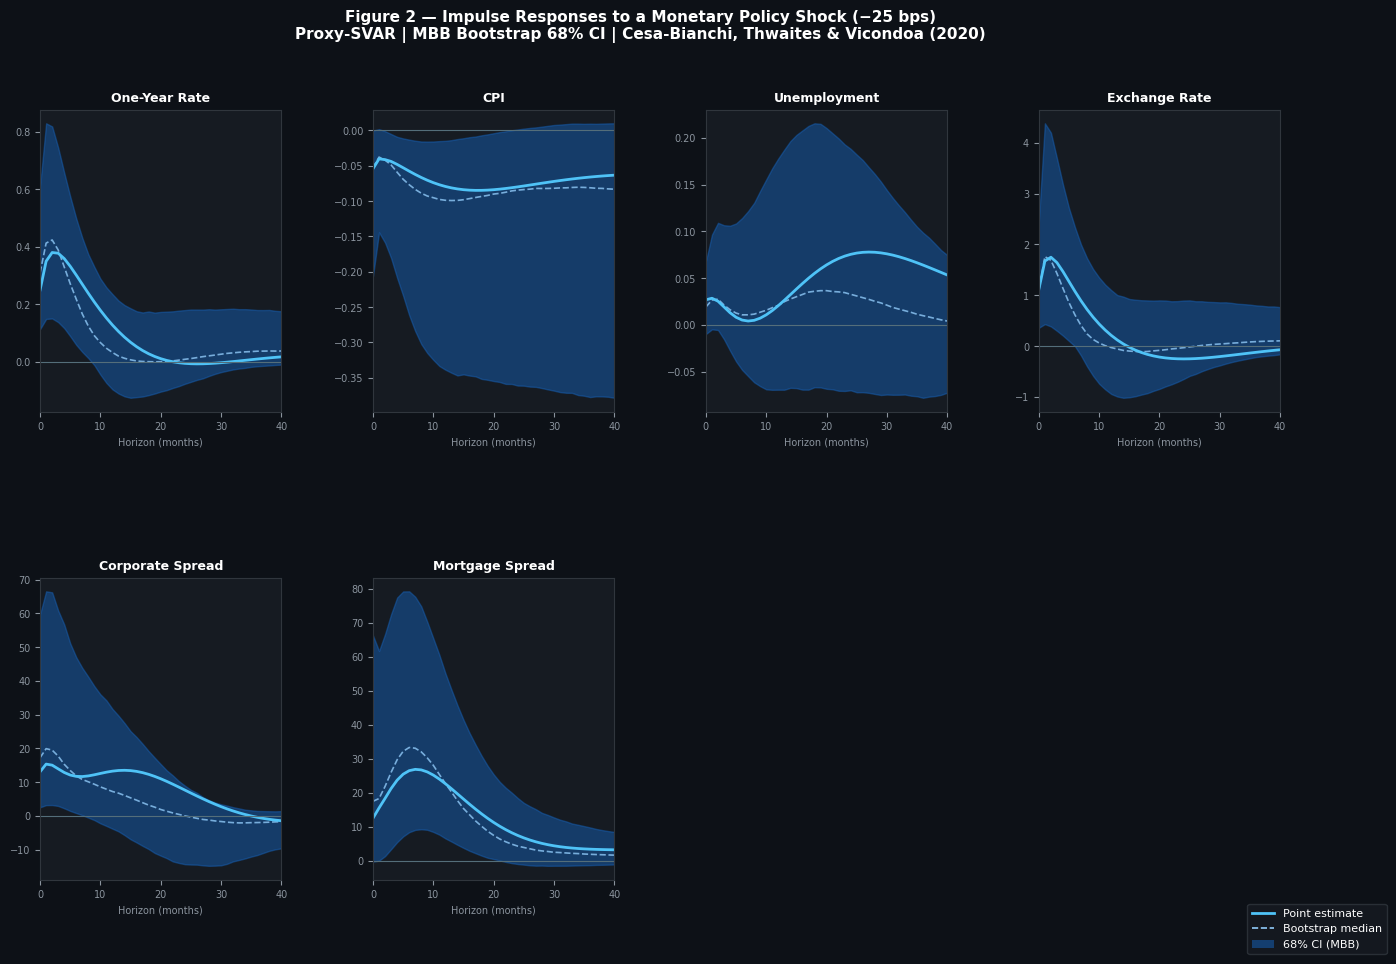

In [20]:
horizon = np.arange(IRF_horizon_h)

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')

n_vars = len(VAR_Zt_Variables)
n_cols = 4
n_rows = 2

gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, hspace=0.55, wspace=0.38)

COLOR_LINE   = '#4fc3f7'
COLOR_FILL   = '#1565c0'
COLOR_MEDIAN = '#90caf9'
COLOR_ZERO   = '#546e7a'

axes = []
for i in range(n_vars):
    row, col = divmod(i, n_cols)
    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)

for i, (ax, label) in enumerate(zip(axes, VAR_Zt_lables)):
    ax.set_facecolor('#161b22')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

    # Confidence band
    ax.fill_between(horizon, irsL[:, i], irsH[:, i],
                    color=COLOR_FILL, alpha=0.45, label=f'{confidence_level}% CI')
    # Median bootstrap
    ax.plot(horizon, irsM[:, i], color=COLOR_MEDIAN,
            linewidth=1.2, linestyle='--', alpha=0.8)
    # Point estimate
    ax.plot(horizon, irf_point[:, i], color=COLOR_LINE,
            linewidth=2.0, label='Point estimate')
    # Zero line
    ax.axhline(0, color=COLOR_ZERO, linewidth=0.8, linestyle='-')

    ax.set_title(label, color='white', fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel('Horizon (months)', color='#8b949e', fontsize=7)
    ax.tick_params(colors='#8b949e', labelsize=7)
    ax.set_xlim(0, IRF_horizon_h - 1)
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))

# Hide unused subplot (7 vars, 8 slots)
axes[-1].set_visible(False)

fig.suptitle(
    'Figure 2 — Impulse Responses to a Monetary Policy Shock (−25 bps)\n'
    'Proxy-SVAR | MBB Bootstrap 68% CI | Cesa-Bianchi, Thwaites & Vicondoa (2020)',
    color='white', fontsize=11, fontweight='bold', y=0.98)

# Shared legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=COLOR_LINE,   linewidth=2,   label='Point estimate'),
    Line2D([0], [0], color=COLOR_MEDIAN, linewidth=1.2, linestyle='--', label='Bootstrap median'),
    Patch(facecolor=COLOR_FILL, alpha=0.5,              label='68% CI (MBB)'),
]
fig.legend(handles=legend_elements, loc='lower right',
           bbox_to_anchor=(0.97, 0.03),
           facecolor='#161b22', edgecolor='#30363d',
           labelcolor='white', fontsize=8)



Part 5